## Customer Segmentation Project


- Mall Customers dataset 
- we will implement K means clustering to check the spending patterns of our customers
- segment the customer spending behaviour


Task:
1. data ingestion/acquisition
2. Data EDA
3. Preprocessing, if needed
4. train a model 
5. Cluster the users 

Optional
6. Tag each cluter with a name and save that column in dataframe

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df = pd.read_csv(url)
df.head()

df.info()

# Dropping unrelated columns that are not needed in clusters

df = df.drop(columns = ['Gender','CustomerID'])

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [34]:
df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


## Determine optimal number of k using elbow method analysis


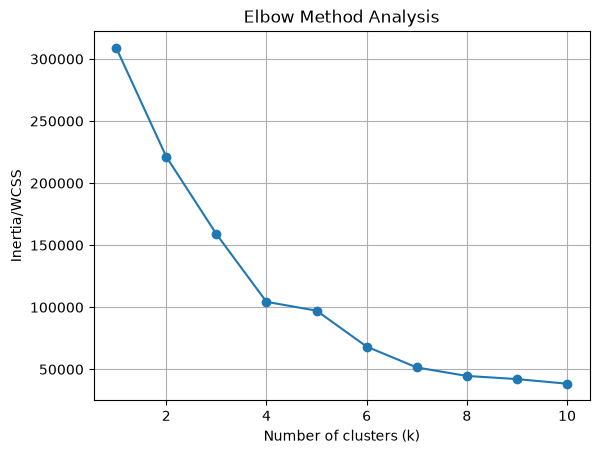

In [41]:
errors = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state= 42)
    kmeans.fit(df)
    errors.append(kmeans.inertia_)

plt.plot(range(1,11), errors, marker = 'o')
plt.title('Elbow Method Analysis')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia/WCSS')
plt.grid()
plt.show()

In [36]:
# Therefore 3 clusters were choosen
model = KMeans( n_clusters= 4, init = 'random', random_state= 42)

model

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [37]:
df['Cluster'] = model.fit_predict(df)

In [38]:
# how far spread out the clusters are
# how good the model is
model.inertia_

104366.151455562

In [39]:
df.sample(5)

df['Cluster'].value_counts()

Cluster
0    95
2    39
3    38
1    28
Name: count, dtype: int64

In [40]:
# Checking the mean of each clusters for each column
cluster_profiles = df.groupby('Cluster').mean()
print(cluster_profiles)

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        44.894737           48.705263               42.631579
1        24.821429           28.714286               74.250000
2        32.692308           86.538462               82.128205
3        40.394737           87.000000               18.631579


#### Here we can see the group behaviour through mean value

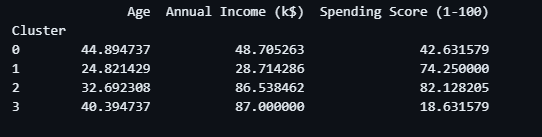

- Cluster 1 are oldest has medium spending score with medium income
- Cluster 2 are young adults has high spending score but has low income
- Cluster 3 are mature adults has high spending score and high income
- Cluster 4 are middle age adults has lowest spending score and highest income


In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (12, 6))

ax[0].scatter(df['sepal length (cm)'], df['sepal width (cm)'], c = df['KClustering'])
ax[0].set_title('Clustering by K Means')


# from the dataset that I already have, we take the REAL species values
# let's see if Kmeans is doing good
ax[1].scatter(df['sepal length (cm)'], df['sepal width (cm)'], c = data.target)
ax[1].set_title('Clustering using the Species column')

plt.tight_layout()
plt.show()